# Tutorial for a new pointing API and a pointing systematics.


In [1]:
import logging
import os
import random
from typing import Any, List, Optional, Union

import astropy.time
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import tomlkit
from numpy.typing import NDArray

import litebird_sim as lbs

logging.getLogger("healpy").setLevel(logging.WARNING)

No protocol specified


Let's define useful function to generate `Simulation` and list of `DetectorInfo`.


In [2]:
telescope = "LFT"

start_time = 0


imo_version = "vPTEP"
imo = lbs.Imo(flatfile_location=lbs.PTEP_IMO_LOCATION)

duration_s = 10
sampling_hz = 19.0
random_seed = 12345


def gen_simulation_and_dets(
    telescope,
    duration_s,
    sampling_hz,
    random_seed,
    hwp_rpm=None,
    scan_strategy=True,
):
    """Generate a simulation and detectors with a argument of scan_strategy.
    If scan_strategy is True, the scanning strategy is set by the IMO file.
    If scan_strategy is False, the spacecraft stops spinning and precession.

    Args:
        telescope (str): Telescope name.
        duration_s (float): Duration of simulation.
        sampling_hz (float): Sampling frequency.
        random_seed (int): Random seed.
        hwp_rpm (float, optional): HWP rotation speed. Defaults to None.
        scan_strategy (bool, optional): If True, the scanning strategy is set by the IMO file. Defaults to True.

    Returns:
        lbs.Simulation
        list: List of detectors.
    """
    sim = lbs.Simulation(
        start_time=start_time, duration_s=duration_s, random_seed=random_seed
    )
    if scan_strategy:
        sim.set_scanning_strategy(
            imo_url=f"/releases/{imo_version}/satellite/scanning_parameters/",
            delta_time_s=1.0 / sampling_hz,
        )
    else:
        sim.set_scanning_strategy(
            scanning_strategy=lbs.SpinningScanningStrategy(
                spin_sun_angle_rad=np.deg2rad(45.0),
                spin_rate_hz=0.0,
                precession_rate_hz=0.0,
            ),
            delta_time_s=1.0 / sampling_hz,
        )
    sim.set_instrument(
        lbs.InstrumentInfo.from_imo(
            imo,
            f"/releases/{imo_version}/satellite/{telescope}/instrument_info",
        )
    )

    if hwp_rpm is not None:
        sim.set_hwp(lbs.IdealHWP(hwp_rpm * 2 * np.pi / 60))
        if sim.instrument is not None:
            sim.instrument.hwp_rpm = hwp_rpm
    else:
        if sim.instrument is not None:
            sim.set_hwp(lbs.IdealHWP(sim.instrument.hwp_rpm * 2 * np.pi / 60))
    dets = []
    path_of_toml = "../test/pointing_sys_reference/mock_focalplane.toml"
    with open(path_of_toml, "r", encoding="utf-8") as toml_file:
        toml_data = tomlkit.parse(toml_file.read())

        telescope_data = toml_data[telescope].unwrap()

        for i in range(len(telescope_data)):
            det_dict = dict(telescope_data[f"det_{i:03}"])
            det = lbs.DetectorInfo.from_dict(det_dict)

            det.sampling_rate_hz = sampling_hz
            dets.append(det)
    return sim, dets


def get_hitmap(nside, pointings):
    """Get hitmap from pointings.

    Args:
        nside (int): nside of healpix.
        pointings (np.ndarray): Pointings of detectors.

    Returns:
        np.ndarray: Hitmap
    """
    npix = hp.nside2npix(nside)
    ipix = hp.ang2pix(nside, pointings[:, :, 0], pointings[:, :, 1])
    hitmap, _ = np.histogram(ipix, bins=np.arange(npix + 1))
    return hitmap

In the new pointing API allows to calculate pointing in the method of `.Observation`
To obtain all detectors pointing that you specified, you just call `Observation.get_pointings("all")` as below:


In [3]:
sim, dets = gen_simulation_and_dets(telescope, duration_s, sampling_hz, random_seed)

sim.create_observations(detectors=dets)

lbs.prepare_pointings(
    sim.observations, sim.instrument, sim.spin2ecliptic_quats, hwp=sim.hwp
)

pointings_no_syst, hwp_angle = sim.observations[0].get_pointings("all")

[2026-07-13 12:21:55,129 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:21:55,131 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.


The same result can be obtained by accessing each instance using a for loop as follows:


In [4]:
pointings_ = []
for cur_obs in sim.observations:
    for det_idx in range(cur_obs.n_detectors):
        pnt, _ = cur_obs.get_pointings(det_idx, pointings_dtype=np.float64)
        pointings_.append(pnt)
pointings_ = np.array(pointings_)

assert np.allclose(pointings_no_syst, pointings_)

Thanks to the new pointing API, we can control the time dependency of the quaternion to generate pointings.
The `Class: PointingSys` contains essential functionality to simulate a systematics that can happen around pointing, e.g. constant offset, vibration and so on.

These systematics need to be simulated on a specific coordinate, such as a Forcal plane coordinate and a spacecraft coordinate.
`PointingSys` can simulate several situations of pointing systematics:

- Forcal plane coordinate
  - Time-independent
    - Global offset: Each detector has an offset of the same magnitude and direction.
    - Individual offset per detector: Each detector has offset of different magnitude and direction.
  - Time-dependent
    - Global offset: Each detector has the same disturbance.
    - Individual disturbance det. by det: Each detector has different disturbance.
- Spacecraft coordinate

  - Time independent
    - Global offset: Spacecraft misinterprets its spin axis.
  - Time-dependent
    - Global disturbance: The whole spacecraft is affected by the same perturbation, e.g. due to a cryogenic system, internal noise of the star tracker.

- HWP coordinate
  - Time-dependent
    - Common disturbance per telescope: Pointing circular disturbance given by wedged HWP (or tilted refrective HWP). This effect rotates pointings around expected pointing direction with a constant angular radius.

Here we describe the use of `PointingSys` to simulate each point.


## FP coord / time-independent / global offset


In [5]:
# rotation axis for the offset in the focal plane coordinate
axes = ["x", "y", "z"]
pointings_list = []
global_offset_deg = 10.0

for ax in axes:
    sim_sys, dets_sys = gen_simulation_and_dets(
        telescope, duration_s, sampling_hz, random_seed
    )

    sim_sys.create_observations(detectors=dets_sys)
    # Define the instance of the `PointingSys`
    pntsys = lbs.PointingSys(sim_sys, sim_sys.observations[0], dets_sys)
    # Add the global offset to the focal plane
    pntsys.focalplane.add_offset(np.deg2rad(global_offset_deg), ax)

    lbs.prepare_pointings(
        sim_sys.observations,
        sim_sys.instrument,
        sim_sys.spin2ecliptic_quats,
        hwp=sim_sys.hwp,
    )

    pointings_sys, hwp_angle = sim_sys.observations[0].get_pointings("all")
    pointings_list.append(pointings_sys)

[2026-07-13 12:22:00,304 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:22:00,305 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
/home/sstellat/LBS/litebird_sim/litebird_sim/pointing_sys.py:607: UserWarning: 
The `Simulation.spin2ecliptic_quats.start_time` and the `Observation.start_time` are not same type, but they are same number. 
So, the `Simulation.spin2ecliptic_quats.start_time` is updated to the `Observation.start_time`.
  warnings.warn(
[2026-07-13 12:22:01,547 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:22:01,548 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
/home/sstellat/LBS/litebird_sim/litebird_sim/pointing_sys.py:607: UserWarning: 
The `Simulation.spin2ecliptic_quats.start_time` and the `Observation.start_time` are not same type, but they are same number. 
S

We can see how the global offset is injected in the pointings in the below hitmap which is calculated with a single timestamp:


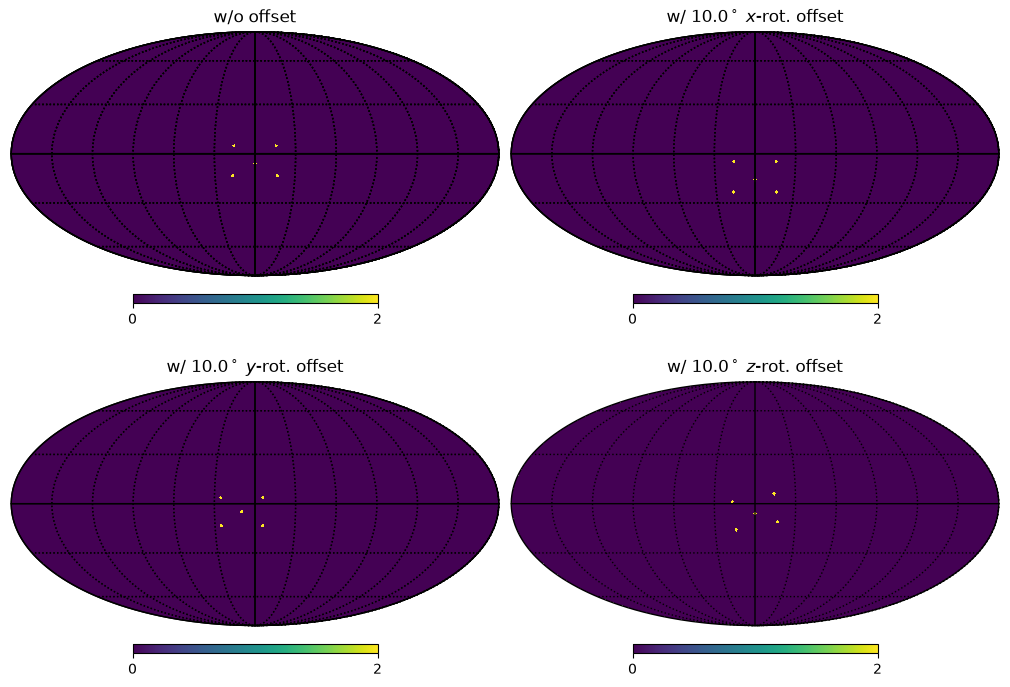

In [6]:
nside = 32
hitmap = get_hitmap(
    nside,
    pointings_no_syst[
        :,
        :1,
        :,
    ],
)

plt.figure(figsize=(10, 7))
hp.mollview(hitmap, sub=(2, 2, 1), title="w/o offset")
hp.graticule()
for i, ax in enumerate(axes):
    hitmap_sys = get_hitmap(nside, pointings_list[i][:, :1])
    hp.mollview(
        hitmap_sys,
        sub=(2, 2, i + 2),
        title=rf"w/ {global_offset_deg}$^\circ$ ${ax}$-rot. offset",
    )
    hp.graticule()

## FP coord / time-independent / individual offset det. by det.


In [7]:
pointings_list = []

sim_sys, dets_sys = gen_simulation_and_dets(
    telescope, duration_s, sampling_hz, random_seed
)

det1_offset = 10.0
uncommon_offsets_deg = [
    0,
    0,
    det1_offset,
    det1_offset,
    0,
    0,
    0,
    0,
    0,
    0,
]  # [det0_top, det0_bottom, det1_top, det1_bottom,...]

sim_sys.create_observations(detectors=dets_sys)

# Just you need to put array of the offsets in the focal plane coordinate
pntsys = lbs.PointingSys(sim_sys, sim_sys.observations[0], dets_sys)
pntsys.focalplane.add_offset(np.deg2rad(uncommon_offsets_deg), "x")
pntsys.focalplane.add_offset(np.deg2rad(uncommon_offsets_deg), "y")


lbs.prepare_pointings(
    sim_sys.observations,
    sim_sys.instrument,
    sim_sys.spin2ecliptic_quats,
    hwp=sim_sys.hwp,
)

pointings_sys, hwp_angle = sim_sys.observations[0].get_pointings("all")
pointings_list.append(pointings_sys)

[2026-07-13 12:22:04,459 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:22:04,459 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.


One detector that has turned 10 deg. on the $x$-axis and then 10 deg. on the $y$-axis can be identified.


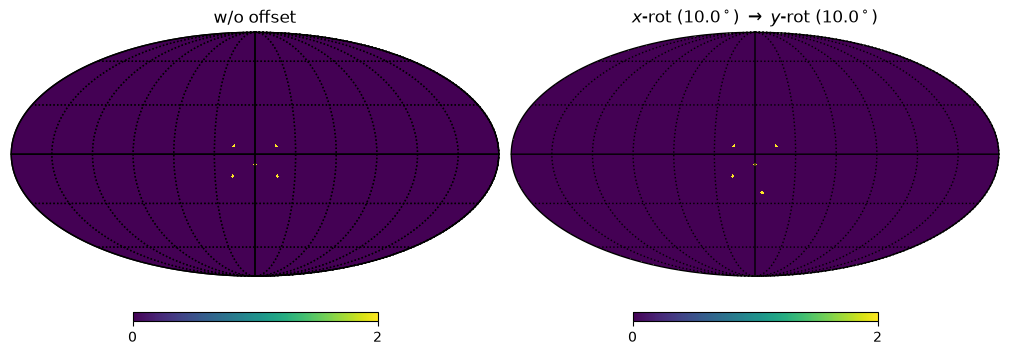

In [8]:
hitmap = get_hitmap(
    nside,
    pointings_no_syst[
        :,
        :1,
        :,
    ],
)

plt.figure(figsize=(10, 7))
hp.mollview(hitmap, sub=(1, 2, 1), title="w/o offset")
hp.graticule()

hitmap_sys = get_hitmap(nside, pointings_list[0][:, :1])
hp.mollview(
    hitmap_sys,
    sub=(1, 2, 2),
    title=rf"$x$-rot ({det1_offset}$^\circ$) $\rightarrow$ $y$-rot ({det1_offset}$^\circ$)",
)
hp.graticule()

## FP coord / time-dependent / global disturbance


In [9]:
duration_s = 10
sampling_hz = 10.0

sim_sys, dets_sys = gen_simulation_and_dets(
    telescope,
    duration_s,
    sampling_hz,
    random_seed,
    scan_strategy=False,  # STOP scanning to see the effect of the white noise
)

sim_sys.create_observations(detectors=dets_sys)

nquats = sim_sys.observations[0].n_samples + 1
pntsys = lbs.PointingSys(sim_sys, sim_sys.observations[0], dets_sys)

# Add the white noise to the focal plane
noise_rad_array_x = np.zeros(nquats)
noise_rad_array_y = np.zeros(nquats)
noise_sigma_deg = 3.0

# make a white noise with the unit of radian.
lbs.add_white_noise(
    noise_rad_array_x, sigma=np.deg2rad(noise_sigma_deg), random=sim_sys.random
)
lbs.add_white_noise(
    noise_rad_array_y, sigma=np.deg2rad(noise_sigma_deg), random=sim_sys.random
)

pntsys.focalplane.add_disturb(noise_rad_array_x, "x")
pntsys.focalplane.add_disturb(noise_rad_array_y, "y")

pointings_list = []
lbs.prepare_pointings(
    sim_sys.observations,
    sim_sys.instrument,
    sim_sys.spin2ecliptic_quats,
    hwp=sim_sys.hwp,
)

pointings_list, _ = sim_sys.observations[0].get_pointings("all")

[2026-07-13 12:22:05,642 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:22:05,643 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.


Within 10 secconds observation with 10 Hz sampling rate, we can see the gaussian stracture in the hitmap due to the white noise that we injected.
Note that we stap the scanning motion.


<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\c'
<>:19: SyntaxWarning: invalid escape sequence '\c'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\c'
<>:19: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_205557/1866300411.py:19: SyntaxWarning: invalid escape sequence '\s'
  title=f"$(\sigma_x,\sigma_y)=({noise_sigma_deg}^\circ, {noise_sigma_deg}^\circ)$",
/tmp/ipykernel_205557/1866300411.py:19: SyntaxWarning: invalid escape sequence '\c'
  title=f"$(\sigma_x,\sigma_y)=({noise_sigma_deg}^\circ, {noise_sigma_deg}^\circ)$",
/tmp/ipykernel_205557/1866300411.py:19: SyntaxWarning: invalid escape sequence '\c'
  title=f"$(\sigma_x,\sigma_y)=({noise_sigma_deg}^\circ, {noise_sigma_deg}^\circ)$",


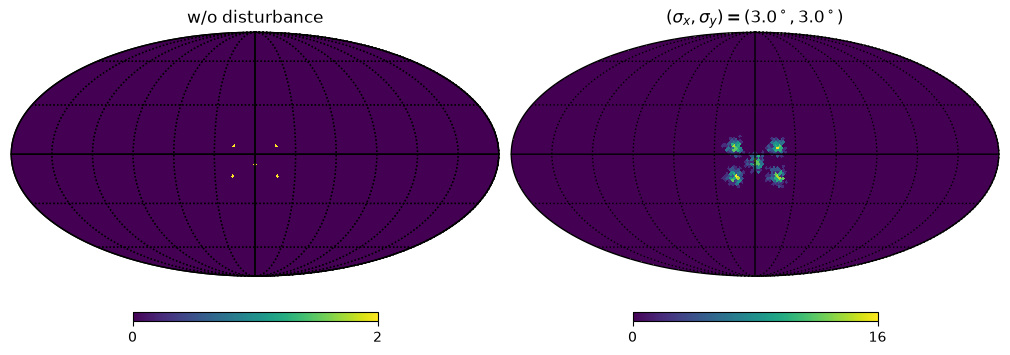

In [10]:
nside = 32
hitmap = get_hitmap(
    nside,
    pointings_no_syst[
        :,
        :1,
        :,
    ],
)

plt.figure(figsize=(10, 7))
hp.mollview(hitmap, sub=(1, 2, 1), title="w/o disturbance")
hp.graticule()

hitmap_sys = get_hitmap(nside, pointings_list)
hp.mollview(
    hitmap_sys,
    sub=(1, 2, 2),
    title=f"$(\sigma_x,\sigma_y)=({noise_sigma_deg}^\circ, {noise_sigma_deg}^\circ)$",
)
hp.graticule()

## FP coord / time-dependent / individual disturbance det. by det.


In [11]:
duration_s = 10
sampling_hz = 10.0

sim_sys, dets_sys = gen_simulation_and_dets(
    telescope, duration_s, sampling_hz, random_seed, scan_strategy=False
)
sim_sys.create_observations(detectors=dets_sys)

nquats = sim_sys.observations[0].n_samples + 1

# make a noise with a shape of (num. of detectors, num. of quats.)
noise_matrix_rad_x = np.zeros([len(dets_sys), nquats])
noise_matrix_rad_y = np.zeros([len(dets_sys), nquats])
noise_sigma_deg = 3.0

for i in range(len(dets_sys)):
    lbs.add_white_noise(
        noise_matrix_rad_x[i, :],
        sigma=np.deg2rad(noise_sigma_deg),
        random=sim_sys.random,
    )
    lbs.add_white_noise(
        noise_matrix_rad_y[i, :],
        sigma=np.deg2rad(noise_sigma_deg),
        random=sim_sys.random,
    )

# [number of detectors, number of quaternions]
print("noise_matrix_rad_x.shape [ndet, nsample]: ", noise_matrix_rad_x.shape)

pntsys = lbs.PointingSys(sim_sys, sim_sys.observations[0], dets_sys)

# Add the white noise to each detector in the focal plane
pntsys.focalplane.add_disturb(noise_matrix_rad_x, "x")
pntsys.focalplane.add_disturb(noise_matrix_rad_y, "y")

pointings_list = []

lbs.prepare_pointings(
    sim_sys.observations,
    sim_sys.instrument,
    sim_sys.spin2ecliptic_quats,
    hwp=sim_sys.hwp,
)

pointings_list, _ = sim_sys.observations[0].get_pointings("all")

[2026-07-13 12:22:06,747 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:22:06,748 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.


noise_matrix_rad_x.shape [ndet, nsample]:  (10, 101)


The middle map is calcurated single timestamp, we can see the pointing of detectors individually subjected to disturbance.

After integrated by time, it will be a gaussian like in the right.


<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_205557/2983040370.py:27: SyntaxWarning: invalid escape sequence '\s'
  title=f"$(\sigma_x,\sigma_y)=({noise_sigma_deg}^\circ, {noise_sigma_deg}^\circ)$"
/tmp/ipykernel_205557/2983040370.py:27: SyntaxWarning: invalid escape sequence '\c'
  title=f"$(\sigma_x,\sigma_y)=({noise_sigma_deg}^\circ, {noise_sigma_deg}^\circ)$"
/tmp/ipykernel_205557/2983040370.py:27: SyntaxWarnin

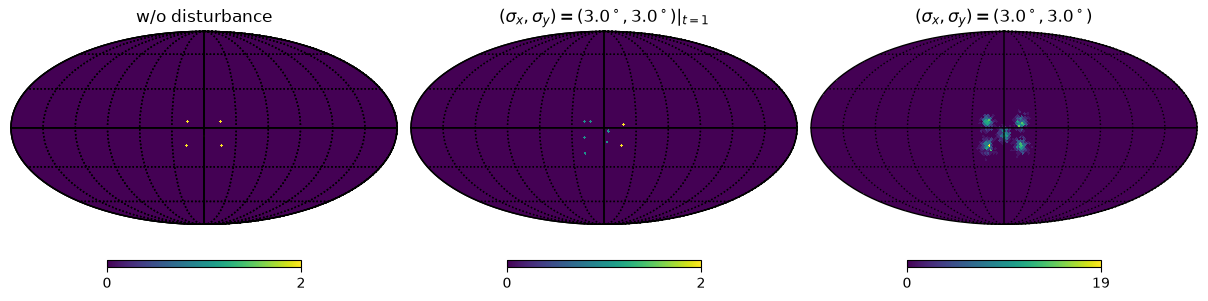

In [12]:
nside = 32
hitmap = get_hitmap(
    nside,
    pointings_no_syst[
        :,
        :1,
        :,
    ],
)

plt.figure(figsize=(12, 7))
hp.mollview(hitmap, sub=(1, 3, 1), title="w/o disturbance")
hp.graticule()

time_snap = 1
hitmap_sys_t1 = get_hitmap(
    nside,
    pointings_list[
        :,
        time_snap - 1 : time_snap,
        :,
    ],
)
hp.mollview(
    hitmap_sys_t1,
    sub=(1, 3, 2),
    title=f"$(\sigma_x,\sigma_y)=({noise_sigma_deg}^\circ, {noise_sigma_deg}^\circ)$"
    + f"$|_{{t={time_snap}}}$",
)
hp.graticule()

hitmap_sys = get_hitmap(nside, pointings_list)
hp.mollview(
    hitmap_sys,
    sub=(1, 3, 3),
    title=f"$(\sigma_x,\sigma_y)=({noise_sigma_deg}^\circ, {noise_sigma_deg}^\circ)$",
)
hp.graticule()

## Spacecraft / time-independent / global offset


In [13]:
# 'x': perpendicular to the scan direction
# 'z': parallel to the scan direction

axes = ["x", "y", "z"]
pointings_list = []
global_offset_deg = 35.0

for ax in axes:
    sim_sys, dets_sys = gen_simulation_and_dets(
        telescope, duration_s, sampling_hz, random_seed
    )
    sim_sys.create_observations(detectors=dets_sys)
    pntsys = lbs.PointingSys(sim_sys, sim_sys.observations[0], dets_sys)

    # Specify `spacecraft` to add the global offset
    pntsys.spacecraft.add_offset(np.deg2rad(global_offset_deg), ax)

    lbs.prepare_pointings(
        sim_sys.observations,
        sim_sys.instrument,
        sim_sys.spin2ecliptic_quats,
        hwp=sim_sys.hwp,
    )

    pointings_sys, hwp_angle = sim_sys.observations[0].get_pointings("all")
    pointings_list.append(pointings_sys)

[2026-07-13 12:22:08,267 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:22:08,268 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:22:08,579 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:22:08,580 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:22:09,073 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:22:09,074 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.


Note that in the FP example, the rotation was attached with respect to the boresight, but in the spacecraft coordinates, the spin axis is the reference. In particular, the $x$-axis offset is perpendicular to the scan direction and the $z$-axis offset is parallel to the scan direction, which changes the physical situation.


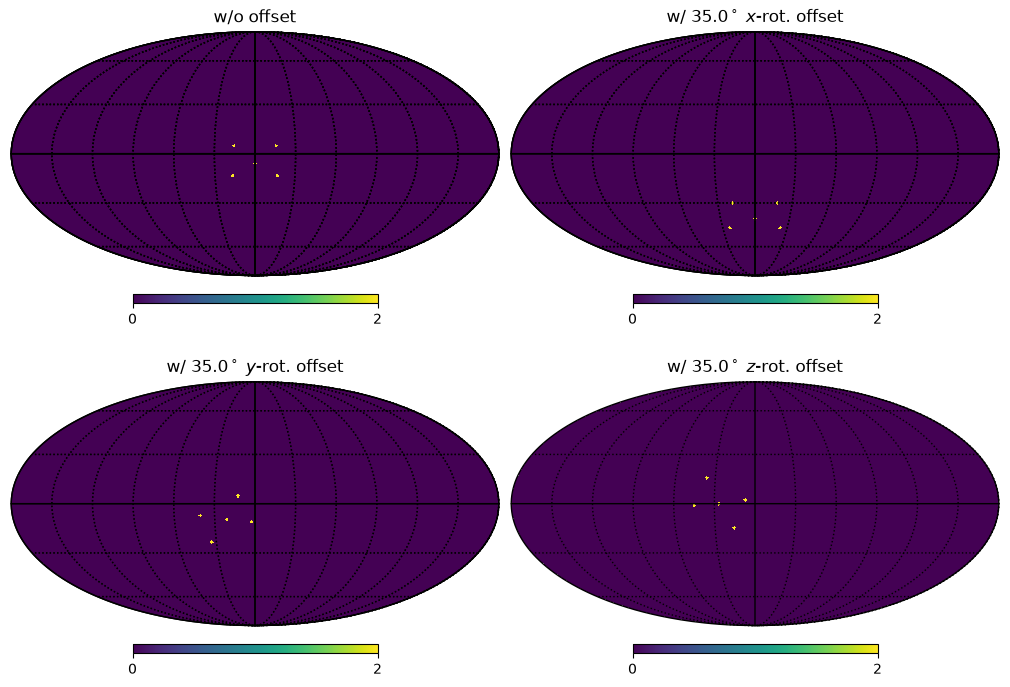

In [14]:
nside = 32
hitmap = get_hitmap(
    nside,
    pointings_no_syst[
        :,
        :1,
        :,
    ],
)

plt.figure(figsize=(10, 7))
hp.mollview(hitmap, sub=(2, 2, 1), title="w/o offset")
hp.graticule()
for i, ax in enumerate(axes):
    hitmap_sys = get_hitmap(nside, pointings_list[i][:, :1])
    hp.mollview(
        hitmap_sys,
        sub=(2, 2, i + 2),
        title=rf"w/ {global_offset_deg}$^\circ$ ${ax}$-rot. offset",
    )
    hp.graticule()

## Spacecraft / time-dependent / global disturbance


In [15]:
duration_s = 10
sampling_hz = 10.0

sim_sys, dets_sys = gen_simulation_and_dets(
    telescope, duration_s, sampling_hz, random_seed, scan_strategy=False
)
sim_sys.create_observations(detectors=dets_sys)

nquats = sim_sys.observations[0].n_samples + 1

noise_rad_array_x = np.zeros(nquats)
noise_rad_array_z = np.zeros(nquats)
noise_sigma_deg = 3.0

# make a white noise with the unit of radian.
lbs.add_white_noise(
    noise_rad_array_x, sigma=np.deg2rad(noise_sigma_deg), random=sim_sys.random
)
lbs.add_white_noise(
    noise_rad_array_z, sigma=np.deg2rad(noise_sigma_deg), random=sim_sys.random
)

pntsys = lbs.PointingSys(sim_sys, sim_sys.observations[0], dets_sys)

# Add the white noise to the spacecraft
pntsys.spacecraft.add_disturb(noise_rad_array_x, "x")
pntsys.spacecraft.add_disturb(noise_rad_array_z, "z")


lbs.prepare_pointings(
    sim_sys.observations,
    sim_sys.instrument,
    sim_sys.spin2ecliptic_quats,
    hwp=sim_sys.hwp,
)

pointings_list, _ = sim_sys.observations[0].get_pointings("all")

[2026-07-13 12:22:11,229 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:22:11,230 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.


We can see the disturbed pointings in the right hitmap.


<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\c'
<>:19: SyntaxWarning: invalid escape sequence '\c'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\c'
<>:19: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_205557/3162785549.py:19: SyntaxWarning: invalid escape sequence '\s'
  title=f"$(\sigma_x,\sigma_z)=({noise_sigma_deg}^\circ, {noise_sigma_deg}^\circ)$",
/tmp/ipykernel_205557/3162785549.py:19: SyntaxWarning: invalid escape sequence '\c'
  title=f"$(\sigma_x,\sigma_z)=({noise_sigma_deg}^\circ, {noise_sigma_deg}^\circ)$",
/tmp/ipykernel_205557/3162785549.py:19: SyntaxWarning: invalid escape sequence '\c'
  title=f"$(\sigma_x,\sigma_z)=({noise_sigma_deg}^\circ, {noise_sigma_deg}^\circ)$",


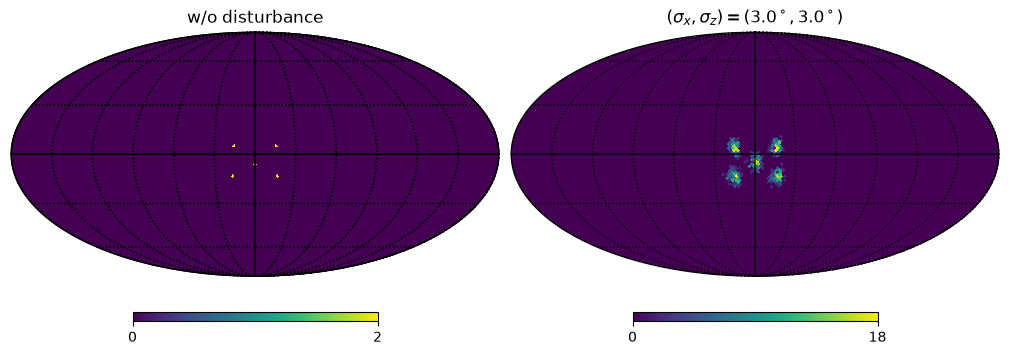

In [16]:
nside = 32
hitmap = get_hitmap(
    nside,
    pointings_no_syst[
        :,
        :1,
        :,
    ],
)

plt.figure(figsize=(10, 7))
hp.mollview(hitmap, sub=(1, 2, 1), title="w/o disturbance")
hp.graticule()

hitmap_sys = get_hitmap(nside, pointings_list)
hp.mollview(
    hitmap_sys,
    sub=(1, 2, 2),
    title=f"$(\sigma_x,\sigma_z)=({noise_sigma_deg}^\circ, {noise_sigma_deg}^\circ)$",
)
hp.graticule()

# Rotational disturbance due to the HWP

## Example of wedged HWP pointing systematics


In [17]:
duration_s = 60
sampling_hz = 19.0
start_time = 0
hwp_rpm = 3

sim_sys, dets_sys = gen_simulation_and_dets(
    telescope, duration_s, sampling_hz, random_seed, hwp_rpm=hwp_rpm, scan_strategy=True
)
sim_sys.create_observations(detectors=dets_sys)

# Define the instance of the `PointingSys`
pntsys = lbs.PointingSys(sim_sys, sim_sys.observations[0], dets_sys)
refractive_idx = 3.1  # refractive index of the saphire
# wedge angle of the HWP, for the visulization it is set to big number to see the effect.
wedge_angle_deg = 3
wedge_angle_rad = np.deg2rad(wedge_angle_deg)

# Set the pointing shift angle from the expected pointing direction i.e. it is a deviation of the pointing direction.
# if pntsys.hwp.tilt_angle_rad = 0.0, the pointing is the same as the expected pointing direction.
# Now, we determin the deviation angle is given by the wedge angle and the refractive index of the HWP.
# Note that we assume the refractive index of ordinary and extra-ordinary axis of HWP has same value.
tilt_angle_rad = pntsys.hwp.get_wedgeHWP_pointing_shift_angle(
    wedge_angle_rad, refractive_idx
)

# Set the HWP rotation speed and the initial tilt (wedge direction) corresponding to the phase of the pointing deviation angle.
ang_speed_radpsec = sim_sys.instrument.hwp_rpm * 2 * np.pi / 60

# Add the HWP rotation disturbance to detector's quaternion in `dets_sys`
pntsys.hwp.add_hwp_rot_disturb(tilt_angle_rad, ang_speed_radpsec)

lbs.prepare_pointings(
    sim_sys.observations,
    sim_sys.instrument,
    sim_sys.spin2ecliptic_quats,
    hwp=sim_sys.hwp,
)

pointings_list, hwpang = sim_sys.observations[0].get_pointings("all")

[2026-07-13 12:22:12,313 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:22:12,314 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.


<>:19: SyntaxWarning: invalid escape sequence '\c'
<>:19: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_205557/533176888.py:19: SyntaxWarning: invalid escape sequence '\c'
  title=f"HWP weadge angle={wedge_angle_deg}$^\circ$ with {hwp_rpm} rpm",


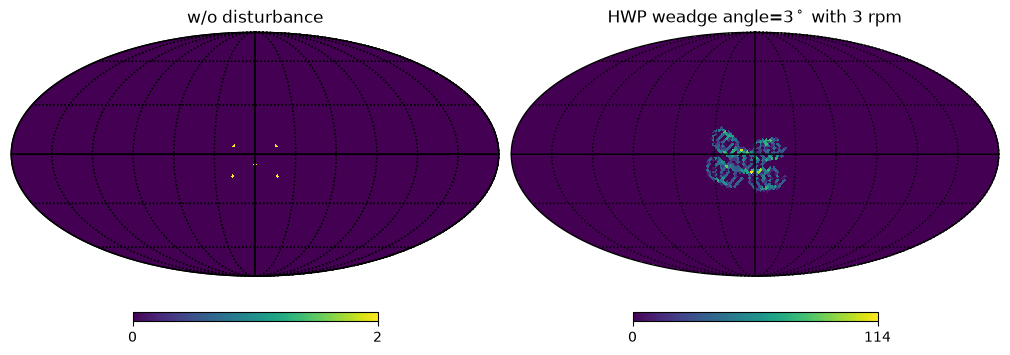

In [18]:
nside = 32
hitmap = get_hitmap(
    nside,
    pointings_no_syst[
        :,
        :1,
        :,
    ],
)

plt.figure(figsize=(10, 7))
hp.mollview(hitmap, sub=(1, 2, 1), title="w/o disturbance")
hp.graticule()

hitmap_sys = get_hitmap(nside, pointings_list)
hp.mollview(
    hitmap_sys,
    sub=(1, 2, 2),
    title=f"HWP weadge angle={wedge_angle_deg}$^\circ$ with {hwp_rpm} rpm",
)
hp.graticule()

## TOD generation

Now, we demonstrate an example of TOD generation with the pointing systematics.
Let's redefine the `Simulation` and list of detectors.


In [19]:
telescope = "LFT"
channel = "L4-140"
detlist = ["000_001_017_QB_140_T", "000_001_017_QB_140_B"]

start_time = 0
"""
imo_version = "vPTEP"
imo = lbs.Imo(flatfile_location=lbs.PTEP_IMO_LOCATION)
"""


mission_time_days = 180
duration_s = mission_time_days * 24 * 3600.0
sampling_hz = 1.0
random_seed = 12345
nside = 64


def gen_sim_and_dets_from_imo(
    telescope, duration_s, sampling_hz, random_seed, hwp_rpm=None, scan_strategy=True
):
    """Generate a simulation and detectors with a argument of scan_strategy.
    If scan_strategy is True, the scanning strategy is set by the IMO file.
    If scan_strategy is False, the spacecraft stops spinning and precession.
    """
    sim = lbs.Simulation(
        start_time=start_time, duration_s=duration_s, random_seed=random_seed
    )
    sim.set_scanning_strategy(
        imo_url=f"/releases/{imo_version}/satellite/scanning_parameters/",
        delta_time_s=1.0 / sampling_hz,
    )
    if scan_strategy:
        sim.set_scanning_strategy(
            imo_url=f"/releases/{imo_version}/satellite/scanning_parameters/",
            delta_time_s=1.0 / sampling_hz,
        )
    else:
        sim.set_scanning_strategy(
            scanning_strategy=lbs.SpinningScanningStrategy(
                spin_sun_angle_rad=np.deg2rad(45.0),
                spin_rate_hz=0.0,
                precession_rate_hz=0.0,
            ),
            delta_time_s=1.0 / sampling_hz,
        )
    sim.set_instrument(
        lbs.InstrumentInfo.from_imo(
            imo,
            f"/releases/{imo_version}/satellite/{telescope}/instrument_info",
        )
    )
    if hwp_rpm is not None:
        sim.set_hwp(lbs.IdealHWP(hwp_rpm * 2 * np.pi / 60))
        if sim.instrument is not None:
            sim.instrument.hwp_rpm = hwp_rpm
    else:
        if sim.instrument is not None:
            sim.set_hwp(lbs.IdealHWP(sim.instrument.hwp_rpm * 2 * np.pi / 60))
    dets = []
    for n_det in detlist:
        det = lbs.DetectorInfo.from_imo(
            url=f"/releases/{imo_version}/satellite/{telescope}/{channel}/{n_det}/detector_info",
            imo=imo,
        )
        det.sampling_rate_hz = sampling_hz
        dets.append(det)

    return sim, dets

In [20]:
# loading channel info
ch_info = []
ch_info.append(
    lbs.FreqChannelInfo.from_imo(
        url=f"/releases/{imo_version}/satellite/{telescope}/{channel}/channel_info",
        imo=imo,
    )
)

[2026-07-13 12:22:13,191 INFO MPI#0000] Generating CMB...
[2026-07-13 12:22:13,229 INFO MPI#0000] Summing components...


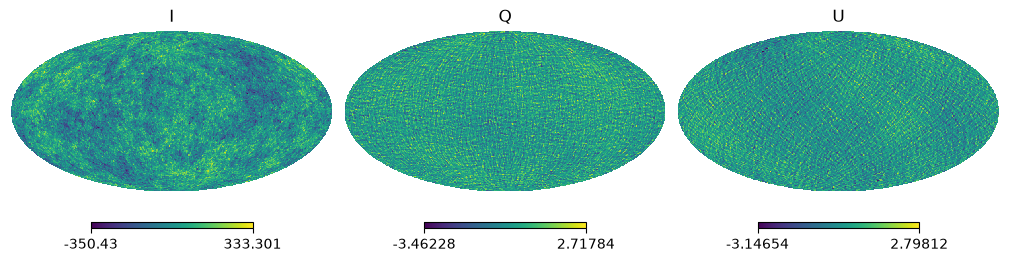

In [21]:
sky_params = lbs.SkyGenerationParams(
    make_cmb=True,
    make_fg=False,
    seed_cmb=random_seed,
    apply_beam=False,  # We apply beam during the interpolation, so we don't apply it here
    bandpass_integration=False,
    units="uK_CMB",
    output_type="alm",
    nside=nside,
)

# get_sky output is now a dictionary containing the spherical harmonics
sky_alms = sim.get_sky(parameters=sky_params, channels=ch_info)

# Extract the alm array (I, Q, U) for conversion
alms_array = sky_alms[channel].values
maps = hp.alm2map(alms_array, nside=nside, pol=True)

plt.figure(figsize=(10, 6))
hp.mollview(maps[0], sub=(1, 3, 1), title="I")
hp.mollview(maps[1], sub=(1, 3, 2), title="Q")
hp.mollview(maps[2], sub=(1, 3, 3), title="U")
plt.show()

## Example of the pointing offset in the spacecraft


In [22]:
# Define `Simulation` and `List[Detector]` without pointing systematics.
sim, dets = gen_sim_and_dets_from_imo(telescope, duration_s, sampling_hz, random_seed)
# Define `Simulation` and `List[Detector]` to be injected pointing systematics.
sim_sys, dets_sys = gen_sim_and_dets_from_imo(
    telescope, duration_s, sampling_hz, random_seed
)
# create the observations
sim.create_observations(detectors=dets)
sim_sys.create_observations(detectors=dets_sys)


# make `PointingSys` instance
pntsys = lbs.PointingSys(sim_sys, sim_sys.observations[0], dets_sys)

[2026-07-13 12:22:14,061 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:22:14,062 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:22:14,825 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:22:14,826 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
/home/sstellat/LBS/litebird_sim/litebird_sim/pointing_sys.py:607: UserWarning: 
The `Simulation.spin2ecliptic_quats.start_time` and the `Observation.start_time` are not same type, but they are same number. 
So, the `Simulation.spin2ecliptic_quats.start_time` is updated to the `Observation.start_time`.
  warnings.warn(


In [23]:
sim.set_hwp(lbs.IdealHWP(sim.instrument.hwp_rpm * 2 * np.pi / 60))  # HWP setup
sim_sys.set_hwp(lbs.IdealHWP(sim_sys.instrument.hwp_rpm * 2 * np.pi / 60))  # HWP setup

for n_det in detlist:
    det = lbs.DetectorInfo.from_imo(
        url=f"/releases/{imo_version}/satellite/{telescope}/{channel}/{n_det}/detector_info",
        imo=imo,
    )
    det.mueller_hwp = np.diag([1.0, 1.0, -1.0, -1.0])

In [24]:
# Add the global offset to the focal plane
global_offset_deg = 0.1
axis = "x"
pntsys.spacecraft.add_offset(np.deg2rad(global_offset_deg), axis)

# prepare the pointing
sim.prepare_pointings()
sim_sys.prepare_pointings()

lbs.precompute_pointings(sim.observations)
lbs.precompute_pointings(sim_sys.observations)

n_obs = len(sim.observations)
pointings = [sim.observations[i_obs].pointing_matrix for i_obs in range(n_obs)]
pointings_sys = [sim_sys.observations[i_obs].pointing_matrix for i_obs in range(n_obs)]

In [25]:
print("Generazione dei beam gaussiani in Alm...")
lmax = 3 * nside - 1
mmax = 4
beam_alms = sim.get_gauss_beam_alms(lmax=lmax)

print("Interpolazione esatta dei TOD tramite ducc0...")

conv_params = lbs.BeamConvolutionParameters(strict_typing=False, lmax=lmax, mmax=mmax)

sim.convolve_sky(sky_alms, beam_alms, convolution_params=conv_params)

sim_sys.convolve_sky(sky_alms, beam_alms, convolution_params=conv_params)

Generazione dei beam gaussiani in Alm...
Interpolazione esatta dei TOD tramite ducc0...


[2026-07-13 12:22:27,351 WARNING MPI#0000] Input beam alms resized, using ℓ_max=191 and m_max=4.
[2026-07-13 12:22:28,655 WARNING MPI#0000] Input beam alms resized, using ℓ_max=191 and m_max=4.
[2026-07-13 12:22:29,926 WARNING MPI#0000] Input beam alms resized, using ℓ_max=191 and m_max=4.
[2026-07-13 12:22:31,216 WARNING MPI#0000] Input beam alms resized, using ℓ_max=191 and m_max=4.


<>:8: SyntaxWarning: invalid escape sequence '\c'
<>:8: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_205557/560238535.py:8: SyntaxWarning: invalid escape sequence '\c'
  label=f"w/ {global_offset_deg}$^\circ$ {axis}-rot. offset",


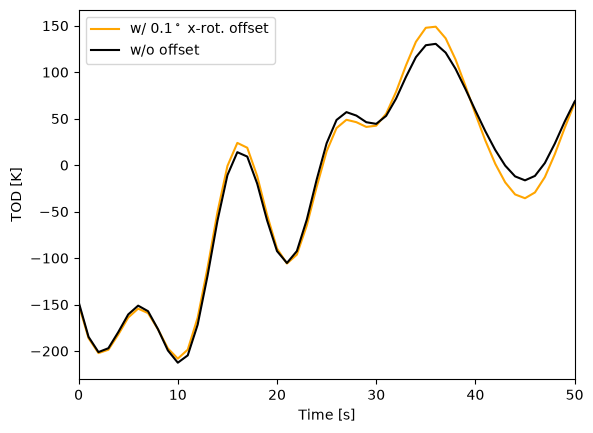

In [26]:
# plot TODs with and without systematics
times = sim.observations[0].get_times()
sample_lim = 100
plt.plot(
    times[:sample_lim],
    sim_sys.observations[0].tod[0][:sample_lim],
    "-",
    label=f"w/ {global_offset_deg}$^\circ$ {axis}-rot. offset",
    color="orange",
)

plt.plot(
    times[:sample_lim],
    sim.observations[0].tod[0][:sample_lim],
    "-",
    label="w/o offset",
    color="black",
)

plt.xlim(0, 50)
plt.xlabel("Time [s]")
plt.ylabel("TOD [K]")
plt.legend()

# Let's make maps with pointing systematics.

We reconstruct the observed maps by TODs which generated by systeamtic pointing (stored in `sim_sys.observations`) with expected pointing (`pointings`).


In [27]:
binner_results = lbs.make_binned_map(
    nside=nside,  # one can set also a different resolution than the input map
    observations=sim_sys.observations,  # includes TOD generated by systematic pointing
    pointings=pointings,  # pointing without systematics
    output_coordinate_system=lbs.CoordinateSystem.Galactic,
)

OpenBLAS warning: precompiled NUM_THREADS exceeded, adding auxiliary array for thread metadata.
To avoid this warning, please rebuild your copy of OpenBLAS with a larger NUM_THREADS setting
or set the environment variable OPENBLAS_NUM_THREADS to 64 or lower


OpenBLAS : Program is Terminated. Because you tried to allocate too many memory regions.
This library was built to support a maximum of 128 threads - either rebuild OpenBLAS
with a larger NUM_THREADS value or set the environment variable OPENBLAS_NUM_THREADS to
a sufficiently small number. This error typically occurs when the software that relies on
OpenBLAS calls BLAS functions from many threads in parallel, or when your computer has more
cpu cores than what OpenBLAS was configured to handle.
BLAS : Bad memory unallocation! :  640  0x7fd36ddc9000


Bottom right is input map of $I$ and middle is observed map with pointing systematiscs.
The left map is the systematics residual map.


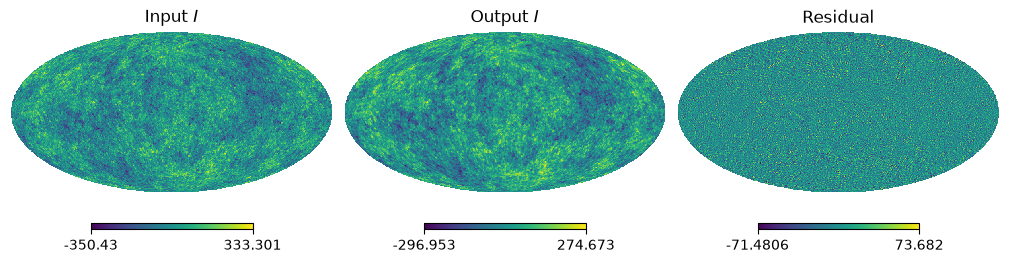

In [28]:
plt.figure(figsize=(10, 6))
hp.mollview(maps[0], sub=(1, 3, 1), title="Input $I$")
hp.mollview(binner_results.binned_map[0], sub=(1, 3, 2), title="Output $I$")
hp.mollview(maps[0] - binner_results.binned_map[0], sub=(1, 3, 3), title="Residual")

## Example of the random disturbance in the spacecraft


In [29]:
# Define `Simulation` and `List[Detector]` without pointing systematics.
duration_s = 3600.0
sampling_hz = 19.0

sim, dets = gen_sim_and_dets_from_imo(telescope, duration_s, sampling_hz, random_seed)
# Define `Simulation` and `List[Detector]` to be injected pointing systematics.
sim_sys, dets_sys = gen_sim_and_dets_from_imo(
    telescope, duration_s, sampling_hz, random_seed
)
# create the observations
sim.create_observations(detectors=dets)
sim_sys.create_observations(detectors=dets_sys)

pntsys = lbs.PointingSys(sim_sys, sim_sys.observations[0], dets_sys)

[2026-07-13 12:22:44,986 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:22:44,987 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:22:45,173 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:22:45,174 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
/home/sstellat/LBS/litebird_sim/litebird_sim/pointing_sys.py:607: UserWarning: 
The `Simulation.spin2ecliptic_quats.start_time` and the `Observation.start_time` are not same type, but they are same number. 
So, the `Simulation.spin2ecliptic_quats.start_time` is updated to the `Observation.start_time`.
  warnings.warn(


In [30]:
nquats = sim_sys.spin2ecliptic_quats.quats.shape[0]

noise_rad_array_x = np.zeros(nquats)
noise_rad_array_y = np.zeros(nquats)
noise_sigma_deg = 0.05

# make a white noise with the unit of radian.
lbs.add_white_noise(
    noise_rad_array_x, sigma=np.deg2rad(noise_sigma_deg), random=sim_sys.random
)
lbs.add_white_noise(
    noise_rad_array_y, sigma=np.deg2rad(noise_sigma_deg), random=sim_sys.random
)
# Add the white noise to the focal plane
pntsys.spacecraft.add_disturb(noise_rad_array_x, "x")
pntsys.spacecraft.add_disturb(noise_rad_array_y, "y")

In [31]:
# prepare the pointing
sim.prepare_pointings()
sim_sys.prepare_pointings()

In [32]:
sim.set_hwp(lbs.IdealHWP(sim.instrument.hwp_rpm * 2 * np.pi / 60))  # HWP setup
sim_sys.set_hwp(lbs.IdealHWP(sim_sys.instrument.hwp_rpm * 2 * np.pi / 60))  # HWP setup

for n_det in detlist:
    det = lbs.DetectorInfo.from_imo(
        url=f"/releases/{imo_version}/satellite/{telescope}/{channel}/{n_det}/detector_info",
        imo=imo,
    )
    det.mueller_hwp = np.diag([1.0, 1.0, -1.0, -1.0])

In [33]:
print("Generazione dei beam gaussiani in Alm...")
lmax = 3 * nside - 1
mmax = 4
beam_alms = sim.get_gauss_beam_alms(lmax=lmax)

print("Interpolazione esatta dei TOD tramite ducc0...")

conv_params = lbs.BeamConvolutionParameters(strict_typing=False, lmax=lmax, mmax=mmax)

sim.convolve_sky(sky_alms, beam_alms, convolution_params=conv_params)

sim_sys.convolve_sky(sky_alms, beam_alms, convolution_params=conv_params)

[2026-07-13 12:22:45,277 WARNING MPI#0000] Input beam alms resized, using ℓ_max=191 and m_max=4.
[2026-07-13 12:22:45,415 WARNING MPI#0000] Input beam alms resized, using ℓ_max=191 and m_max=4.


Generazione dei beam gaussiani in Alm...
Interpolazione esatta dei TOD tramite ducc0...


[2026-07-13 12:22:45,552 WARNING MPI#0000] Input beam alms resized, using ℓ_max=191 and m_max=4.
[2026-07-13 12:22:45,691 WARNING MPI#0000] Input beam alms resized, using ℓ_max=191 and m_max=4.


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\c'
<>:7: SyntaxWarning: invalid escape sequence '\c'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\c'
<>:7: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_205557/2055642132.py:7: SyntaxWarning: invalid escape sequence '\s'
  label=f"w/ disturb. $(\sigma_x, \sigma_y)=({noise_sigma_deg}^\circ, {noise_sigma_deg}^\circ)$",
/tmp/ipykernel_205557/2055642132.py:7: SyntaxWarning: invalid escape sequence '\c'
  label=f"w/ disturb. $(\sigma_x, \sigma_y)=({noise_sigma_deg}^\circ, {noise_sigma_deg}^\circ)$",
/tmp/ipykernel_205557/2055642132.py:7: SyntaxWarning: invalid escape sequence '\c'
  label=f"w/ disturb. $(\sigma_x, \sigma_y)=({noise_sigma_deg}^\circ, {noise_sigma_deg}^\circ)$",


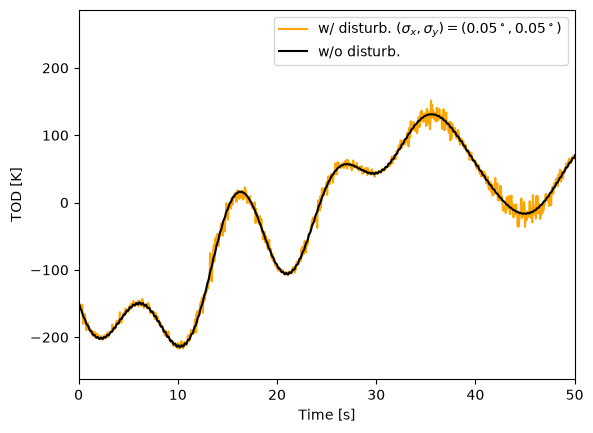

In [34]:
# plot TODs with and without systematics
times = sim.observations[0].get_times()
plt.plot(
    times,
    sim_sys.observations[0].tod[0],
    "-",
    label=f"w/ disturb. $(\sigma_x, \sigma_y)=({noise_sigma_deg}^\circ, {noise_sigma_deg}^\circ)$",
    color="orange",
)

plt.plot(times, sim.observations[0].tod[0], "-", label="w/o disturb.", color="black")

plt.xlim(0, 50)
plt.xlabel("Time [s]")
plt.ylabel("TOD [K]")
plt.legend()

# Examples with latest IMO version

In [35]:
telescope = "LMHFT"
imo_location = "/home/sstellat/LBS/IMo/"
case = "Option2"
imo_version = "IMo_vPostKDP2_" + case

n_dets = 10
nside = 32
FS = 19.0

print("Loading IMO...")
imo = lbs.Imo(flatfile_location=imo_location)

mission_time_hours = 0.05
start_time = astropy.time.Time("2025-01-01T00:00:00")
SEED = 12345

Loading IMO...


In [36]:
def gen_simulations_and_dets(
    telescope,
    mission_time_hours,
    FS,
    SEED,
    channel_name=None,
    detnames=None,
    scan_strategy=True,
):
    sim = lbs.Simulation(
        base_path="./",
        start_time=start_time,
        duration_s=mission_time_hours * 3600,
        imo=imo,
        random_seed=SEED,
    )

    sim.set_instrument(
        lbs.InstrumentInfo.from_imo(
            imo, f"/releases/{imo_version}/{telescope}/instrument_info"
        )
    )

    if scan_strategy:
        sim.set_scanning_strategy(
            lbs.SpinningScanningStrategy.from_imo(
                url=f"/releases/{imo_version}/Observation/Scanning_Strategy",
                imo=imo,
            ),
            delta_time_s=1.0 / FS,
        )
    else:
        sim.set_scanning_strategy(
            scanning_strategy=lbs.SpinningScanningStrategy(
                spin_sun_angle_rad=np.deg2rad(45.0),
                spin_rate_hz=0.0,
                precession_rate_hz=0.0,
            ),
            delta_time_s=1.0 / FS,
        )

    sim.set_hwp(lbs.IdealHWP(sim.instrument.hwp_rpm * 2 * np.pi / 60))

    if channel_name is None:
        channel_name = sim.instrument.channel_names[0]

    chinfo = lbs.FreqChannelInfo.from_imo(
        url=f"/releases/{imo_version}/{telescope}/{channel_name}/channel_info",
        imo=imo,
    )

    if detnames is None:
        detnames = chinfo.detector_names[0:n_dets]

    dets = []
    for dn in detnames:
        det = lbs.DetectorInfo.from_imo(
            url=f"/releases/{imo_version}/{telescope}/{channel_name}/{dn}/detector_info",
            imo=imo,
        )
        det.mueller_hwp = np.diag([1.0, 1.0, -1.0, -1.0])
        det.sampling_rate_hz = FS
        dets.append(det)

    sim.create_observations(
        detectors=dets,
        n_blocks_det=1,
        n_blocks_time=1,
        split_list_over_processes=False,
        tod_dtype=np.float64,
    )
    return sim, dets, chinfo


def get_hitmap(
    nside: int,
    pointings: Union[List[NDArray[np.float64]], NDArray[np.float64]],
    comm: Optional[Any] = None,
) -> NDArray[np.int64]:
    npix = hp.nside2npix(nside)
    local_hitmap = np.zeros(npix, dtype=np.int64)
    ptg_list = [pointings] if isinstance(pointings, np.ndarray) else pointings

    for pts_chunk in ptg_list:
        pts_arr = np.asarray(pts_chunk)
        theta_flat = pts_arr[:, :, 0].ravel()
        phi_flat = pts_arr[:, :, 1].ravel()
        ipix = hp.ang2pix(nside, theta_flat, phi_flat)
        local_hitmap += np.bincount(ipix, minlength=npix).astype(np.int64)
    return local_hitmap

In [37]:
print("Generating simulations...")
# Baseline (Scan Strategy + No Systematics)
sim, dets, _ = gen_simulations_and_dets(telescope, mission_time_hours, FS, SEED)
sim.prepare_pointings()
sim.precompute_pointings()
pointings_nosys = [sim.observations[0].pointing_matrix]

# TEST 1: Global Offset on Focal Plane (Es. 10 degrees on X axis)
global_offset_deg = 10.0
sim_fp_offset, dets_fp, _ = gen_simulations_and_dets(
    telescope, mission_time_hours, FS, SEED
)
pntsys_fp = lbs.PointingSys(sim_fp_offset, sim_fp_offset.observations[0], dets_fp)
pntsys_fp.focalplane.add_offset(np.deg2rad(global_offset_deg), "x")

sim_fp_offset.prepare_pointings()
sim_fp_offset.precompute_pointings()
pointings_fp_offset = [sim_fp_offset.observations[0].pointing_matrix]

# TEST 2: Jitter Disturbance on Spacecraft (Es. White Noise with sigma 3 degrees)
noise_sigma_deg = 3.0
sim_sc_disturb, dets_sc, _ = gen_simulations_and_dets(
    telescope, mission_time_hours, FS, SEED, scan_strategy=False
)  # Scan disabled to see the noise
pntsys_sc = lbs.PointingSys(sim_sc_disturb, sim_sc_disturb.observations[0], dets_sc)

nquats = sim_sc_disturb.observations[0].n_samples + 1
noise_rad_array_x = np.zeros(nquats)
noise_rad_array_z = np.zeros(nquats)

lbs.add_white_noise(
    noise_rad_array_x, sigma=np.deg2rad(noise_sigma_deg), random=sim_sc_disturb.random
)
lbs.add_white_noise(
    noise_rad_array_z, sigma=np.deg2rad(noise_sigma_deg), random=sim_sc_disturb.random
)

pntsys_sc.spacecraft.add_disturb(noise_rad_array_x, "x")
pntsys_sc.spacecraft.add_disturb(noise_rad_array_z, "z")

sim_sc_disturb.prepare_pointings()
sim_sc_disturb.precompute_pointings()
pointings_sc_disturb = [sim_sc_disturb.observations[0].pointing_matrix]

[2026-07-13 12:22:46,418 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:22:46,419 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.


Generating simulations...


[2026-07-13 12:22:46,637 WARNING MPI#0000] Detector '002_000_XX_077_000': mueller_hwp is not a 4x4 numpy array (found type <class 'dict'>, shape None)
[2026-07-13 12:22:46,638 WARNING MPI#0000] Detector '002_000_XX_077_090': mueller_hwp is not a 4x4 numpy array (found type <class 'dict'>, shape None)
[2026-07-13 12:22:46,640 WARNING MPI#0000] Detector '002_001_XX_077_045': mueller_hwp is not a 4x4 numpy array (found type <class 'dict'>, shape None)
[2026-07-13 12:22:46,642 WARNING MPI#0000] Detector '002_001_XX_077_135': mueller_hwp is not a 4x4 numpy array (found type <class 'dict'>, shape None)
[2026-07-13 12:22:46,643 WARNING MPI#0000] Detector '002_002_XX_077_000': mueller_hwp is not a 4x4 numpy array (found type <class 'dict'>, shape None)
[2026-07-13 12:22:46,645 WARNING MPI#0000] Detector '002_002_XX_077_090': mueller_hwp is not a 4x4 numpy array (found type <class 'dict'>, shape None)
[2026-07-13 12:22:46,646 WARNING MPI#0000] Detector '002_003_XX_077_045': mueller_hwp is not a

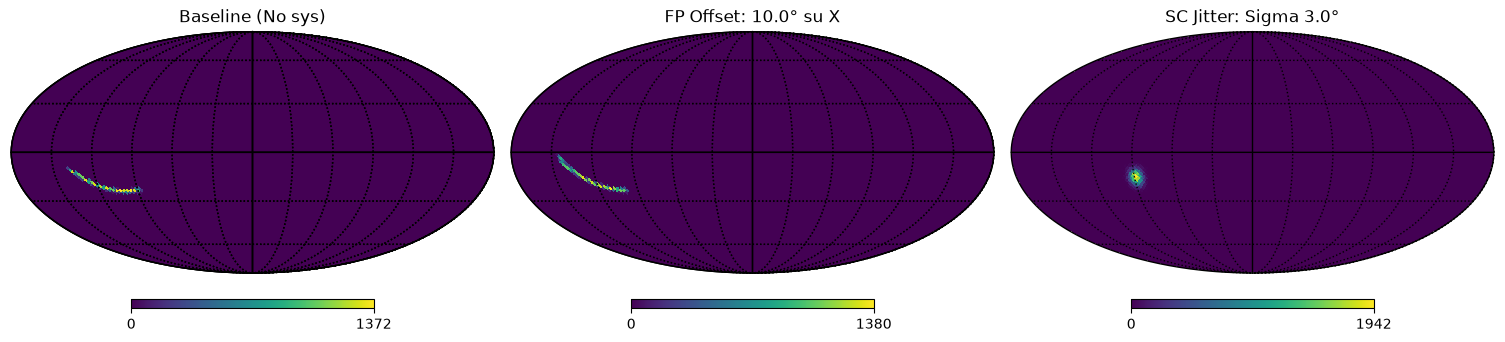

In [38]:
hitmap_nosys = get_hitmap(nside, pointings_nosys)
hitmap_fp_offset = get_hitmap(nside, pointings_fp_offset)
hitmap_sc_disturb = get_hitmap(nside, pointings_sc_disturb)

plt.figure(figsize=(15, 5))
hp.mollview(hitmap_nosys, sub=(1, 3, 1), title="Baseline (No sys)")
hp.graticule()

hp.mollview(
    hitmap_fp_offset, sub=(1, 3, 2), title=f"FP Offset: {global_offset_deg}° su X"
)
hp.graticule()

hp.mollview(
    hitmap_sc_disturb, sub=(1, 3, 3), title=f"SC Jitter: Sigma {noise_sigma_deg}°"
)
hp.graticule()

plt.show()

## Example of HWP wedge/wobble for latest IMo


In [39]:
os.environ["NPY_DISABLE_CPU_FEATURES"] = "AVX512F,AVX2,FMA3"


import healpy as hp
import litebird_sim as lbs
import numpy as np


import matplotlib.pyplot as plt

import astropy.time

from numpy.typing import NDArray
from typing import Optional, Any, Union, List


SEED = 67
random.seed(SEED)
np.random.seed(SEED)

In [40]:
comm = lbs.MPI_COMM_WORLD
rank = comm.Get_rank()
size = comm.Get_size()

print("MPI rank {} out of {}".format(rank, size))

telescope = "LMHFT"
imo_location = "/home/sstellat/LBS/IMo/"
case = "Option2"
imo_version = "IMo_vPostKDP2_" + case

n_dets = 2

nside = 512
lmax = 3 * nside - 1
mmax = 4
FS = 19  # sampling frequency in Hz

print(
    "paramers set to: n_dets={}, nside={}, lmax={}, mmax={}".format(
        n_dets, nside, lmax, mmax
    )
)

print("Loading IMO...")
imo = lbs.Imo(flatfile_location=imo_location)

mission_time_hours = 5
start_time = astropy.time.Time("2025-01-01T00:00:00")

MPI rank 0 out of 1
paramers set to: n_dets=2, nside=512, lmax=1535, mmax=4
Loading IMO...


In [41]:
print("Creating simulation...")


def gen_simulations_and_dets(
    telescope: str,
    mission_time_hours: float,
    FS: float,
    SEED: int,
    channel_name=None,
    detnames=None,
):
    sim = lbs.Simulation(
        base_path="./",
        start_time=start_time,
        duration_s=mission_time_hours * 3600,
        imo=imo,
        # mpi_comm=comm, <--- needed if parallelizing
        random_seed=SEED,
    )

    print("Setting instrument info...")
    sim.set_instrument(
        lbs.InstrumentInfo.from_imo(
            imo,
            f"/releases/{imo_version}/{telescope}/instrument_info",
        )
    )

    print("Setting scanning strategy...")
    sim.set_scanning_strategy(
        lbs.SpinningScanningStrategy.from_imo(
            url=f"/releases/{imo_version}/Observation/Scanning_Strategy",
            imo=imo,
        ),
        delta_time_s=1 / FS,
    )

    print("Setting HWP...")
    sim.set_hwp(lbs.IdealHWP(sim.instrument.hwp_rpm * 2 * np.pi / 60))  # aggiunto io

    if channel_name is None:
        channel_name = sim.instrument.channel_names[0]

    chinfo = lbs.FreqChannelInfo.from_imo(
        url=f"/releases/{imo_version}/{telescope}/{channel_name}/channel_info",
        imo=imo,
    )
    if detnames is None:
        detnames = chinfo.detector_names[0:n_dets]

    print("Selecting detectors...")
    dets = []
    for idn, dn in enumerate(detnames):
        det = lbs.DetectorInfo.from_imo(
            url=f"/releases/{imo_version}/{telescope}/{channel_name}/{dn}/detector_info",
            imo=imo,
        )

        det.mueller_hwp = np.diag([1.0, 1.0, -1.0, -1.0])
        det.sampling_rate_hz = FS
        dets.append(det)

    # comm.barrier()

    print("Creating observations...")
    sim.create_observations(
        detectors=dets,
        n_blocks_det=1,
        n_blocks_time=1,
        split_list_over_processes=False,
        tod_dtype=np.float64,
    )
    return sim, dets, chinfo

Creating simulation...


In [42]:
sim, dets, chinfo = gen_simulations_and_dets(telescope, mission_time_hours, FS, SEED)
sim_wedge, _, _ = gen_simulations_and_dets(telescope, mission_time_hours, FS, SEED)
sim_wobble, _, _ = gen_simulations_and_dets(telescope, mission_time_hours, FS, SEED)

[2026-07-13 12:22:48,653 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:22:48,654 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.


Setting instrument info...
Setting scanning strategy...


[2026-07-13 12:23:07,553 WARNING MPI#0000] Detector '002_000_XX_077_000': mueller_hwp is not a 4x4 numpy array (found type <class 'dict'>, shape None)
[2026-07-13 12:23:07,569 WARNING MPI#0000] Detector '002_000_XX_077_090': mueller_hwp is not a 4x4 numpy array (found type <class 'dict'>, shape None)
[2026-07-13 12:23:07,575 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:23:07,576 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.


Setting HWP...
Selecting detectors...
Creating observations...
Setting instrument info...
Setting scanning strategy...


[2026-07-13 12:23:26,468 WARNING MPI#0000] Detector '002_000_XX_077_000': mueller_hwp is not a 4x4 numpy array (found type <class 'dict'>, shape None)
[2026-07-13 12:23:26,472 WARNING MPI#0000] Detector '002_000_XX_077_090': mueller_hwp is not a 4x4 numpy array (found type <class 'dict'>, shape None)
[2026-07-13 12:23:26,482 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:23:26,483 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.


Setting HWP...
Selecting detectors...
Creating observations...
Setting instrument info...
Setting scanning strategy...


[2026-07-13 12:23:45,398 WARNING MPI#0000] Detector '002_000_XX_077_000': mueller_hwp is not a 4x4 numpy array (found type <class 'dict'>, shape None)
[2026-07-13 12:23:45,400 WARNING MPI#0000] Detector '002_000_XX_077_090': mueller_hwp is not a 4x4 numpy array (found type <class 'dict'>, shape None)


Setting HWP...
Selecting detectors...
Creating observations...


In [43]:
# pointings no sys
sim.prepare_pointings()
sim.precompute_pointings()
pointings_nosys = [sim.observations[0].pointing_matrix]

In [44]:
# pointings with HWP wedge
wedge_angle_arcmin = 10

wedge_angle_rad = np.deg2rad(wedge_angle_arcmin / 60.0)

hwp_rpm = sim_wedge.instrument.hwp_rpm
ang_speed_radpsec = hwp_rpm * 2 * np.pi / 60
f_hwp = hwp_rpm / 60.0

pntwedge = lbs.PointingSys(sim_wedge, sim_wedge.observations[0], dets)

refractive_idx = 2.5  # HWP refractive index or equivalent value for metamaterial
tilt_angle_rad = pntwedge.hwp.get_wedgeHWP_pointing_shift_angle(
    wedge_angle_rad, refractive_idx
)
pntwedge.hwp.add_hwp_rot_disturb(tilt_angle_rad, ang_speed_radpsec, 0.0)

sim_wedge.prepare_pointings()
sim_wedge.precompute_pointings()
pointings_wedge = [sim_wedge.observations[0].pointing_matrix]

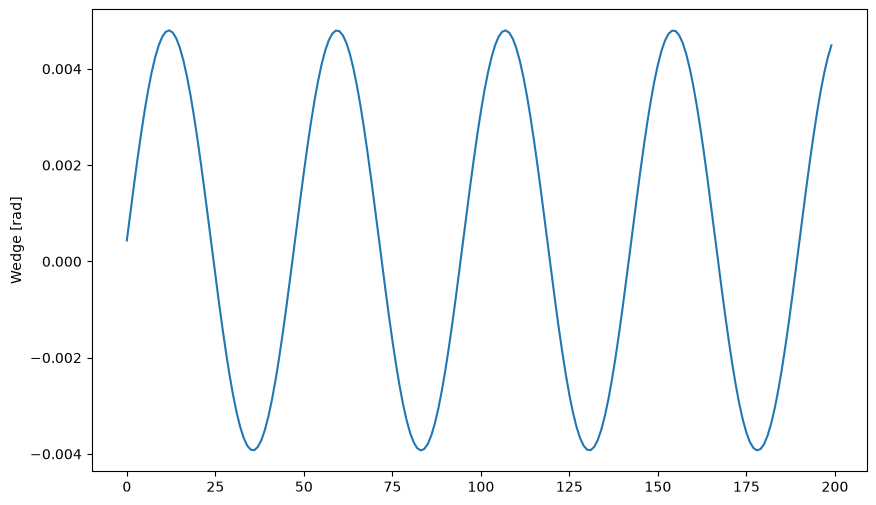

In [45]:
# pointing with wobbling HWP

# The wobbling is defined as a time-dependent wedge angle, you can plug in any function of time to define the wobbling.
# Here for example we use a sinusoidal function.
# You have to define an array for the wobbling angle in radian, and then use the function `get_wedgeHWP_pointing_shift_angle` to get the corresponding pointing shift angle.
# The shape of the wobbling angle array should be the same as the number of quaternions in the simulation.
# nquats = sim_wobble.spin2ecliptic_quats.quats.shape[0]
# You can use the function `add_hwp_rot_disturb` to add the wobbling disturbance to the HWP.
# We provide an example of a sinusoidal wobbling with an amplitude of 10 arcmin and a frequency of 0.5 Hz (half of the HWP rotation frequency).


wobbling_amplitude_arcmin = 10
wobbling_offset_arcmin = 1
wobbling_freq = 0.5 * f_hwp
nquats = sim_wobble.spin2ecliptic_quats.quats.shape[0]  # number of quaternions

t = np.arange(nquats) / FS
pntwobble = lbs.PointingSys(sim_wobble, sim_wobble.observations[0], dets)

wobbling_angle_rad = np.deg2rad(wobbling_amplitude_arcmin / 60.0) * np.sin(
    2 * np.pi * t * wobbling_freq
) + np.deg2rad(wobbling_offset_arcmin / 60.0)
wobbling_tilt_angle_rad = pntwobble.hwp.get_wedgeHWP_pointing_shift_angle(
    wobbling_angle_rad, refractive_idx
)

plt.figure(figsize=(10, 6))
plt.plot(np.asarray(wobbling_tilt_angle_rad)[0:200])
plt.ylabel("Wedge [rad]")
pntwobble = lbs.PointingSys(sim_wobble, sim_wobble.observations[0], dets)

refractive_idx = 2.5  # HWP refractive index or equivalent value for metamaterial
tilt_angle_rad = pntwobble.hwp.get_wedgeHWP_pointing_shift_angle(
    wobbling_angle_rad, refractive_idx
)
pntwobble.hwp.add_hwp_rot_disturb(tilt_angle_rad, ang_speed_radpsec, 0.0)

sim_wobble.prepare_pointings()
sim_wobble.precompute_pointings()
pointings_wobble = [sim_wobble.observations[0].pointing_matrix]

In [46]:
hitmap_nosys = get_hitmap(nside, pointings_nosys)
hitmap_wedge = get_hitmap(nside, pointings_wedge)
hitmap_wobble = get_hitmap(nside, pointings_wobble)

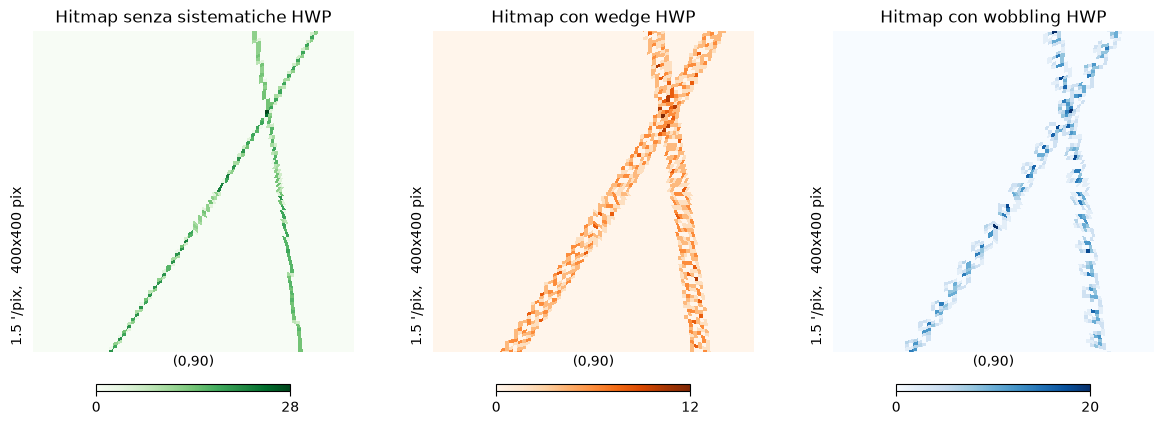

In [47]:
plt.figure(figsize=(12, 4))
hp.gnomview(
    hitmap_nosys,
    rot=(0, 90),
    xsize=400,
    cmap="Greens",
    sub=(1, 3, 1),
    title="Hitmap senza sistematiche HWP",
)
hp.gnomview(
    hitmap_wedge,
    rot=(0, 90),
    xsize=400,
    cmap="Oranges",
    sub=(1, 3, 2),
    title="Hitmap con wedge HWP",
)
hp.gnomview(
    hitmap_wobble,
    rot=(0, 90),
    xsize=400,
    cmap="Blues",
    sub=(1, 3, 3),
    title="Hitmap con wobbling HWP",
)

## Example of full Pipeline simulation for wedge and wobble systematics: from TOD to Maps.

In [48]:
SEED = 67
random.seed(SEED)
np.random.seed(SEED)

In [49]:
comm = lbs.MPI_COMM_WORLD
rank = comm.Get_rank()
size = comm.Get_size()

print("MPI rank {} out of {}".format(rank, size))

telescope = "LMHFT"
imo_location = "/home/sstellat/LBS/IMo/"
case = "Option2"
imo_version = "IMo_vPostKDP2_" + case

n_dets = 2

nside = 512
lmax = 3 * nside - 1
mmax = 4
FS = 19  # sampling frequency in Hz

print(
    "paramers set to: n_dets={}, nside={}, lmax={}, mmax={}".format(
        n_dets, nside, lmax, mmax
    )
)

print("Loading IMO...")
imo = lbs.Imo(flatfile_location=imo_location)

mission_time_hours = 4
start_time = astropy.time.Time("2025-01-01T00:00:00")

MPI rank 0 out of 1
paramers set to: n_dets=2, nside=512, lmax=1535, mmax=4
Loading IMO...


In [50]:
print("Creating simulation...")


def gen_simulations_and_dets(
    telescope: str,
    mission_time_hours: float,
    FS: float,
    SEED: int,
    channel_name=None,
    detnames=None,
):
    sim = lbs.Simulation(
        base_path="./",
        start_time=start_time,
        duration_s=mission_time_hours * 3600,
        imo=imo,
        # mpi_comm=comm, <--- needed if parallelizing
        random_seed=SEED,
    )

    print("Setting instrument info...")
    sim.set_instrument(
        lbs.InstrumentInfo.from_imo(
            imo,
            f"/releases/{imo_version}/{telescope}/instrument_info",
        )
    )

    print("Setting scanning strategy...")
    sim.set_scanning_strategy(
        lbs.SpinningScanningStrategy.from_imo(
            url=f"/releases/{imo_version}/Observation/Scanning_Strategy",
            imo=imo,
        ),
        delta_time_s=1 / FS,
    )

    print("Setting HWP...")
    sim.set_hwp(lbs.IdealHWP(sim.instrument.hwp_rpm * 2 * np.pi / 60))

    if channel_name is None:
        channel_name = sim.instrument.channel_names[0]

    chinfo = lbs.FreqChannelInfo.from_imo(
        url=f"/releases/{imo_version}/{telescope}/{channel_name}/channel_info",
        imo=imo,
    )
    if detnames is None:
        detnames = chinfo.detector_names[0:n_dets]

    print("Selecting detectors...")
    dets = []
    for idn, dn in enumerate(detnames):
        det = lbs.DetectorInfo.from_imo(
            url=f"/releases/{imo_version}/{telescope}/{channel_name}/{dn}/detector_info",
            imo=imo,
        )

        det.mueller_hwp = np.diag([1.0, 1.0, -1.0, -1.0])
        det.sampling_rate_hz = FS
        dets.append(det)

    # comm.barrier()

    print("Creating observations...")
    sim.create_observations(
        detectors=dets,
        n_blocks_det=1,
        n_blocks_time=1,
        split_list_over_processes=False,
        tod_dtype=np.float64,
    )
    return sim, dets, chinfo

Creating simulation...


In [51]:
sim, dets, chinfo = gen_simulations_and_dets(telescope, mission_time_hours, FS, SEED)
sim_wedge, _, _ = gen_simulations_and_dets(telescope, mission_time_hours, FS, SEED)
sim_wobble, _, _ = gen_simulations_and_dets(telescope, mission_time_hours, FS, SEED)

[2026-07-13 12:23:46,924 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:23:46,925 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.


Setting instrument info...
Setting scanning strategy...


[2026-07-13 12:24:02,082 WARNING MPI#0000] Detector '002_000_XX_077_000': mueller_hwp is not a 4x4 numpy array (found type <class 'dict'>, shape None)
[2026-07-13 12:24:02,084 WARNING MPI#0000] Detector '002_000_XX_077_090': mueller_hwp is not a 4x4 numpy array (found type <class 'dict'>, shape None)
[2026-07-13 12:24:02,091 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:24:02,092 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.


Setting HWP...
Selecting detectors...
Creating observations...
Setting instrument info...
Setting scanning strategy...


[2026-07-13 12:24:17,138 WARNING MPI#0000] Detector '002_000_XX_077_000': mueller_hwp is not a 4x4 numpy array (found type <class 'dict'>, shape None)
[2026-07-13 12:24:17,140 WARNING MPI#0000] Detector '002_000_XX_077_090': mueller_hwp is not a 4x4 numpy array (found type <class 'dict'>, shape None)
[2026-07-13 12:24:17,147 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 12:24:17,147 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.


Setting HWP...
Selecting detectors...
Creating observations...
Setting instrument info...
Setting scanning strategy...


[2026-07-13 12:24:32,240 WARNING MPI#0000] Detector '002_000_XX_077_000': mueller_hwp is not a 4x4 numpy array (found type <class 'dict'>, shape None)
[2026-07-13 12:24:32,242 WARNING MPI#0000] Detector '002_000_XX_077_090': mueller_hwp is not a 4x4 numpy array (found type <class 'dict'>, shape None)


Setting HWP...
Selecting detectors...
Creating observations...


In [52]:
# pointings no sys
sim.prepare_pointings()
sim.precompute_pointings()
pointings_nosys = [sim.observations[0].pointing_matrix]

In [53]:
# pointings with HWP wedge
wedge_angle_arcmin = 5

wedge_angle_rad = np.deg2rad(wedge_angle_arcmin / 60.0)

hwp_rpm = sim_wedge.instrument.hwp_rpm
ang_speed_radpsec = hwp_rpm * 2 * np.pi / 60
f_hwp = hwp_rpm / 60.0

pntwedge = lbs.PointingSys(sim_wedge, sim_wedge.observations[0], dets)

refractive_idx = 2.5
tilt_angle_rad = pntwedge.hwp.get_wedgeHWP_pointing_shift_angle(
    wedge_angle_rad, refractive_idx
)
pntwedge.hwp.add_hwp_rot_disturb(tilt_angle_rad, ang_speed_radpsec, 0.0)

sim_wedge.prepare_pointings()
sim_wedge.precompute_pointings()
pointings_wedge = [sim_wedge.observations[0].pointing_matrix]

Text(0, 0.5, 'Wedge [rad]')

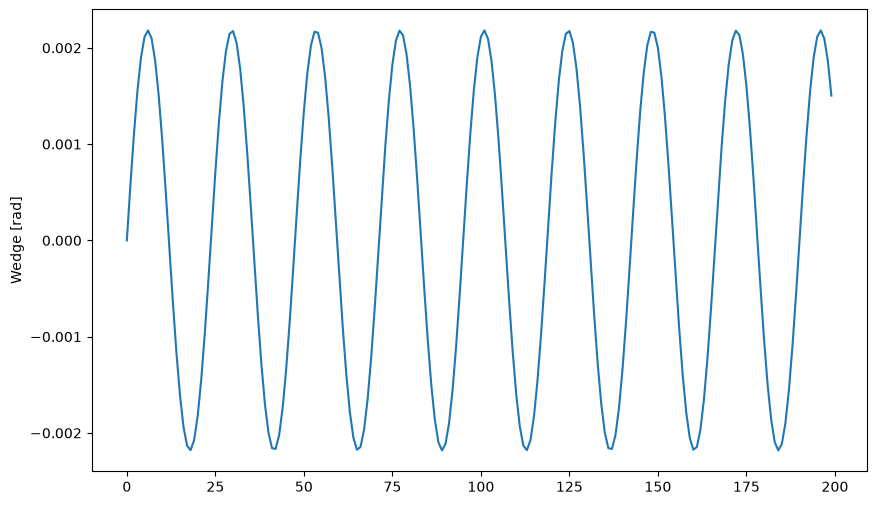

In [54]:
# pointings with HWP wobbling
wobbling_amplitude_arcmin = 5
wobbling_offset_arcmin = 0
wobbling_freq = 1 * f_hwp
nquats = sim_wobble.spin2ecliptic_quats.quats.shape[0]

t = np.arange(nquats) / FS
pntwobble = lbs.PointingSys(sim_wobble, sim_wobble.observations[0], dets)


wobbling_angle_rad = np.deg2rad(wobbling_amplitude_arcmin / 60.0) * np.sin(
    2 * np.pi * t * wobbling_freq
) + np.deg2rad(wobbling_offset_arcmin / 60.0)
wobbling_tilt_angle_rad = pntwobble.hwp.get_wedgeHWP_pointing_shift_angle(
    wobbling_angle_rad, refractive_idx
)
plt.figure(figsize=(10, 6))
plt.plot(np.asarray(wobbling_tilt_angle_rad)[0:200])
plt.ylabel("Wedge [rad]")

In [55]:
pntwobble = lbs.PointingSys(sim_wobble, sim_wobble.observations[0], dets)

refractive_idx = 2.5
tilt_angle_rad = pntwobble.hwp.get_wedgeHWP_pointing_shift_angle(
    wobbling_angle_rad, refractive_idx
)
pntwobble.hwp.add_hwp_rot_disturb(tilt_angle_rad, ang_speed_radpsec, 0.0)

sim_wobble.prepare_pointings()
sim_wobble.precompute_pointings()
pointings_wobble = [sim_wobble.observations[0].pointing_matrix]

In [56]:
sky_params = lbs.SkyGenerationParams(
    make_cmb=True,
    make_fg=False,
    seed_cmb=SEED,
    apply_beam=False,
    bandpass_integration=False,
    units="uK_CMB",
    output_type="alm",
    nside=nside,
)

sky_alms = sim.get_sky(parameters=sky_params, channels=chinfo)

[2026-07-13 12:24:32,896 INFO MPI#0000] Generating CMB...
[2026-07-13 12:24:33,346 INFO MPI#0000] Summing components...


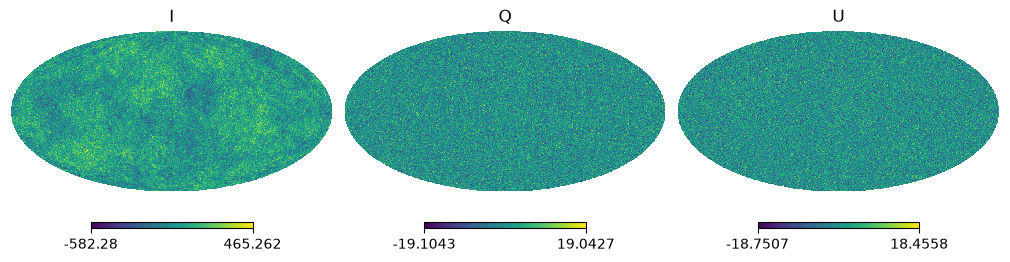

In [57]:
alms_array = sky_alms[sim.instrument.channel_names[0]].values
cmb_map = hp.alm2map(alms_array, nside=nside, pol=True)

plt.figure(figsize=(10, 6))
hp.mollview(cmb_map[0], sub=(1, 3, 1), title="I")
hp.mollview(cmb_map[1], sub=(1, 3, 2), title="Q")
hp.mollview(cmb_map[2], sub=(1, 3, 3), title="U")
plt.show()

In [58]:
print("Generazione dei beam gaussiani in Alm...")
beam_alms = sim.get_gauss_beam_alms(lmax=lmax)

print("Interpolazione esatta dei TOD tramite ducc0...")

conv_params = lbs.BeamConvolutionParameters(strict_typing=False, lmax=lmax, mmax=mmax)

sim.convolve_sky(sky_alms, beam_alms, convolution_params=conv_params)

sim_wedge.convolve_sky(sky_alms, beam_alms, convolution_params=conv_params)

sim_wobble.convolve_sky(sky_alms, beam_alms, convolution_params=conv_params)

[2026-07-13 12:24:34,430 WARNING MPI#0000] Input beam alms resized, using ℓ_max=1535 and m_max=4.


Generazione dei beam gaussiani in Alm...
Interpolazione esatta dei TOD tramite ducc0...


[2026-07-13 12:24:36,171 WARNING MPI#0000] Input beam alms resized, using ℓ_max=1535 and m_max=4.
[2026-07-13 12:24:38,089 WARNING MPI#0000] Input beam alms resized, using ℓ_max=1535 and m_max=4.
[2026-07-13 12:24:39,868 WARNING MPI#0000] Input beam alms resized, using ℓ_max=1535 and m_max=4.
[2026-07-13 12:24:41,673 WARNING MPI#0000] Input beam alms resized, using ℓ_max=1535 and m_max=4.
[2026-07-13 12:24:43,550 WARNING MPI#0000] Input beam alms resized, using ℓ_max=1535 and m_max=4.


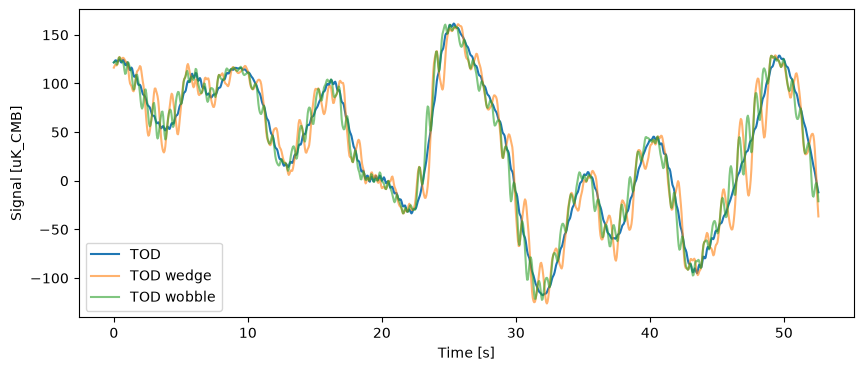

In [59]:
plt.figure(figsize=(10, 4))
plt.plot(t[0:1000], sim.observations[0].tod[0][0:1000], label="TOD")
plt.plot(
    t[0:1000], sim_wedge.observations[0].tod[0][0:1000], label="TOD wedge", alpha=0.6
)
plt.plot(
    t[0:1000], sim_wobble.observations[0].tod[0][0:1000], label="TOD wobble", alpha=0.6
)

plt.xlabel("Time [s]")
plt.ylabel("Signal [uK_CMB]")
plt.legend()
plt.show()

In [60]:
# PSD computation
from scipy.signal import periodogram

f, psd = periodogram(sim.observations[0].tod[0], fs=FS, scaling="density")
_, psd_wedge = periodogram(sim_wedge.observations[0].tod[0], fs=FS, scaling="density")
_, psd_wobble = periodogram(sim_wobble.observations[0].tod[0], fs=FS, scaling="density")

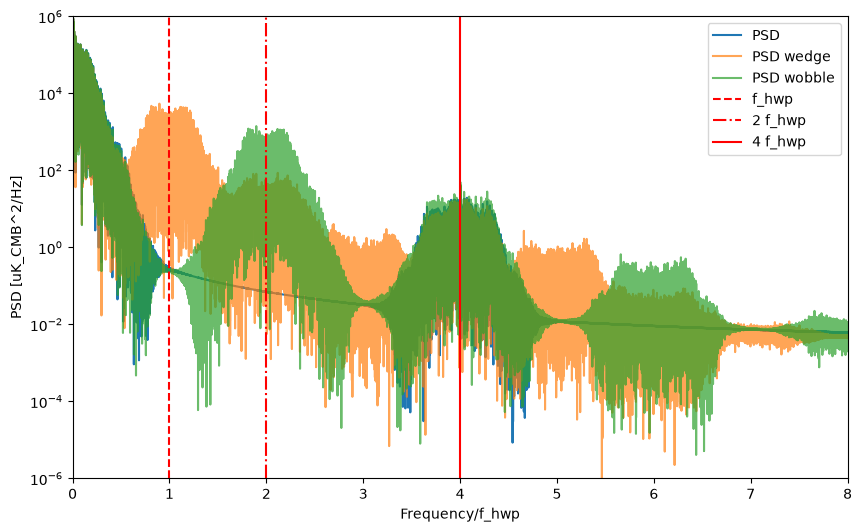

In [61]:
plt.figure(figsize=(10, 6))
plt.semilogy(
    f / f_hwp,
    psd,
    label="PSD",
)
plt.semilogy(f / f_hwp, psd_wedge, label="PSD wedge", alpha=0.7)
plt.semilogy(f / f_hwp, psd_wobble, label="PSD wobble", alpha=0.7)

plt.axvline(x=1, color="r", linestyle="--", label="f_hwp")
plt.axvline(x=2, color="r", linestyle="-.", label="2 f_hwp")
plt.axvline(x=4, color="r", linestyle="-", label="4 f_hwp")

plt.ylabel("PSD [uK_CMB^2/Hz]")
plt.xlabel("Frequency/f_hwp")
plt.ylim(1e-6, 1e6)
plt.xlim(0, 8)
plt.legend()

In [62]:
binner_results = sim.make_binned_map(
    nside=nside,  # one can set also a different resolution than the input map
    output_coordinate_system=lbs.CoordinateSystem.Galactic,
)

out_map = binner_results.binned_map  # this is the map coming from the binned map-maker

In [63]:
del sim_wedge.observations[0].pointing_matrix
sim_wedge.observations[0].pointing_matrix = sim.observations[
    0
].pointing_matrix  # update the pointing matrix of the wedge simulation to be the same as the one without systematics

binner_results_wedge = sim_wedge.make_binned_map(
    nside=nside,  # one can set also a different resolution than the input map
    output_coordinate_system=lbs.CoordinateSystem.Galactic,
)

out_map_wedge = (
    binner_results_wedge.binned_map
)  # this is the map coming from the binned map-maker

In [64]:
del sim_wobble.observations[0].pointing_matrix
sim_wobble.observations[0].pointing_matrix = sim.observations[0].pointing_matrix


binner_results_wobble = sim_wobble.make_binned_map(
    nside=nside,
    output_coordinate_system=lbs.CoordinateSystem.Galactic,
)

out_map_wobble = binner_results_wobble.binned_map

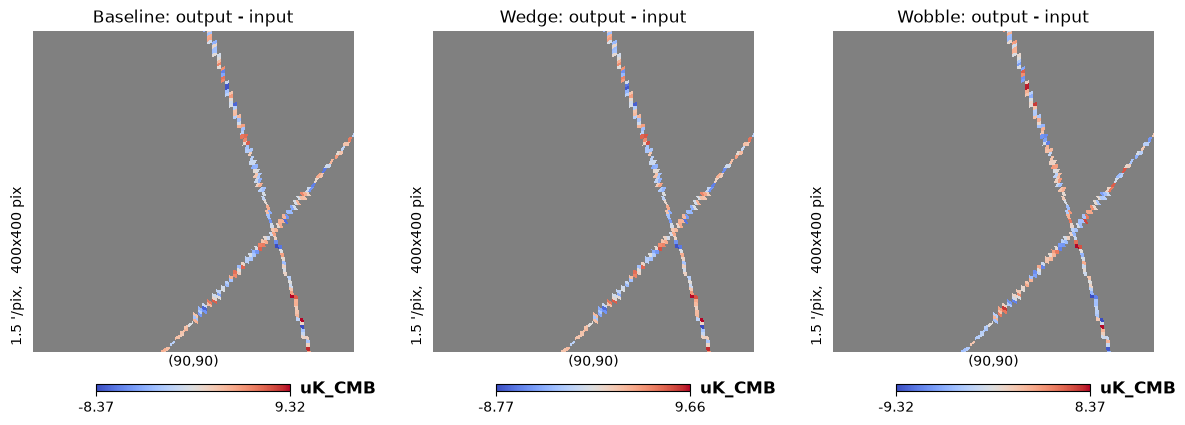

In [65]:
plt.figure(figsize=(12, 4))

mask = (out_map[1] != hp.UNSEEN) & (out_map_wedge[1] != hp.UNSEEN)

hp.gnomview(
    np.where(mask, out_map[1] - cmb_map[1], hp.UNSEEN),
    rot=(90, 90),
    xsize=400,
    sub=(1, 3, 1),
    title="Baseline: output - input",
    unit="uK_CMB",
    cmap="coolwarm",
)

mask = (out_map[1] != hp.UNSEEN) & (out_map_wedge[1] != hp.UNSEEN)

hp.gnomview(
    np.where(mask, out_map_wedge[1] - cmb_map[1], hp.UNSEEN),
    rot=(90, 90),
    xsize=400,
    sub=(1, 3, 2),
    title="Wedge: output - input",
    unit="uK_CMB",
    cmap="coolwarm",
)

mask_wobble = (out_map[1] != hp.UNSEEN) & (out_map_wobble[1] != hp.UNSEEN)

hp.gnomview(
    np.where(mask_wobble, cmb_map[1] - out_map[1], hp.UNSEEN),
    rot=(90, 90),
    xsize=400,
    sub=(1, 3, 3),
    title="Wobble: output - input",
    unit="uK_CMB",
    cmap="coolwarm",
)